# AI & ML with Python

Open this notebook directly in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Anukriti-Bansal/Basic-Python-for-ML/blob/main/AI_ML_Python.ipynb)

# Pharmacology Tutorial: Drug Classification
This notebook demonstrates a complete Machine Learning workflow for classifying drugs based on patient characteristics.

#### Dataset:
**Drug classification dataset:**

https://www.kaggle.com/datasets/prathamtripathi/drug-classification

### Learning Outcomes:
1. **Python Basics**: Syntax and variable handling.
2. **Data Loading**: Using Pandas to read CSV data.
3. **Data Visualization**: Exploring distributions with Seaborn/Matplotlib.
4. **Machine Learning**: Building a classifier with Scikit-Learn.
5. **Evaluation**: Measuring model performance.



#### **Problem Statement**

Given patient information such as:

- Age
- Gender
- Blood Pressure
- Cholesterol Level
- Sodium-to-Potassium Ratio

Can AI predict which drug should be prescribed?

This notebook demonstrates the complete AI workflow:

Patient Data → Data Analysis → Machine Learning Model → Drug Prediction


# Section 1: Python Basics
**Variables**

In [10]:
# Integrer
age = 45

# String
gender = "Female"

# Float
na_to_k = 18.5

print("Python Basics")
print(age)
print(gender)
print(na_to_k)

Python Basics
45
Female
18.5


**Lists**

In [11]:
drugs = ["DrugA", "DrugB", "DrugC"]

print(drugs)

print("First drug:", drugs[0])

['DrugA', 'DrugB', 'DrugC']
First drug: DrugA


**Dictionaries**

In [12]:
patient = {
    "Age": 45,
    "Gender": "Female",
    "BP": "HIGH"
}

print(patient)

{'Age': 45, 'Gender': 'Female', 'BP': 'HIGH'}


**Conditional Statements**

In [13]:
age = 60

if age > 50:
    print("Senior Patient")
else:
    print("Adult Patient")

Senior Patient


In [15]:
# Reading input from the user

age = int(input("Enter patient age: "))

if age > 50:
    print("Senior Patient")
else:
    print("Adult Patient")

Enter patient age: 45
Adult Patient


**Loops**

In [16]:
drugs = ["DrugA", "DrugB", "DrugC"]

for drug in drugs:
    print(drug)

DrugA
DrugB
DrugC


# Section 2: Import Libraries


In [18]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Section 3: Load Dataset

###Read Dataset

In [23]:
df = pd.read_csv("drug200.csv")

df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


###Explore Dataset

In [30]:
# Shape of Dataset
print("Shape of dataset")
print(df.shape)
print("------------------------------------")

# Dataset information
print("Dataset Info")
print(df.info())
print("------------------------------------")

# Statistical summary
print("Statistical Summary")
print(df.describe())
print("------------------------------------")

# Count number of classes
print("Number of classes")
print(df['Drug'].value_counts())
print("------------------------------------")

# Check missing values
print("Missing values")
print(df.isnull().sum())
print("------------------------------------")


Shape of dataset
(200, 6)
------------------------------------
Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
None
------------------------------------
Statistical Summary
              Age     Na_to_K
count  200.000000  200.000000
mean    44.315000   16.084485
std     16.544315    7.223956
min     15.000000    6.269000
25%     31.000000   10.445500
50%     45.000000   13.936500
75%     58.000000   19.380000
max     74.000000   38.247000
------------------------------------
Number of classes
Drug
DrugY    91
drugX    54
drugA 

# Section 3: Data Visualization

### Distribution of Age

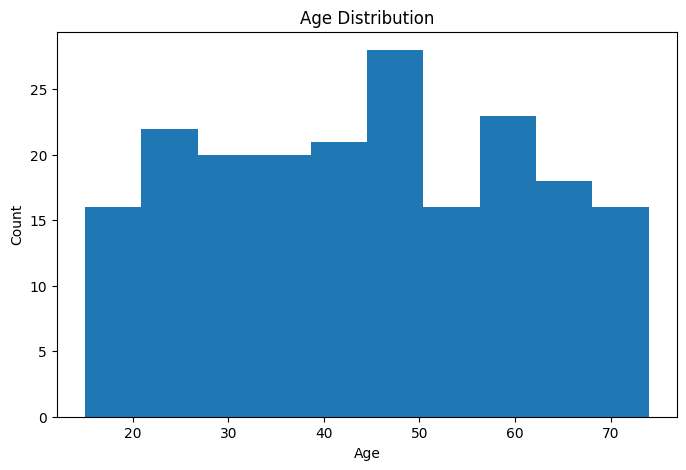

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

### Drug Distribution

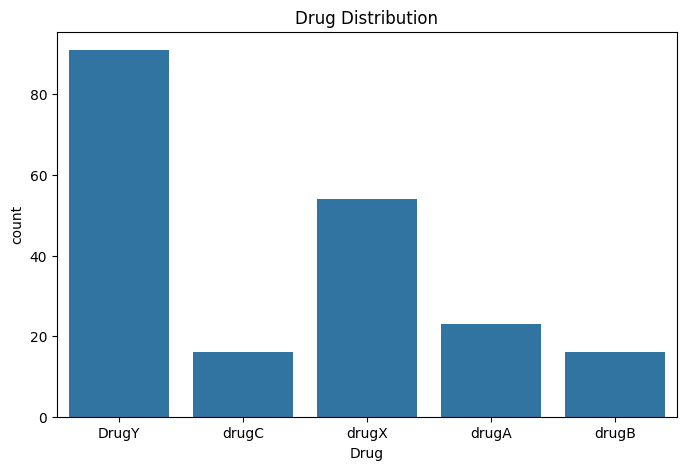

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(x='Drug', data=df)

plt.title("Drug Distribution")

plt.show()

### Na_to_K vs Drug

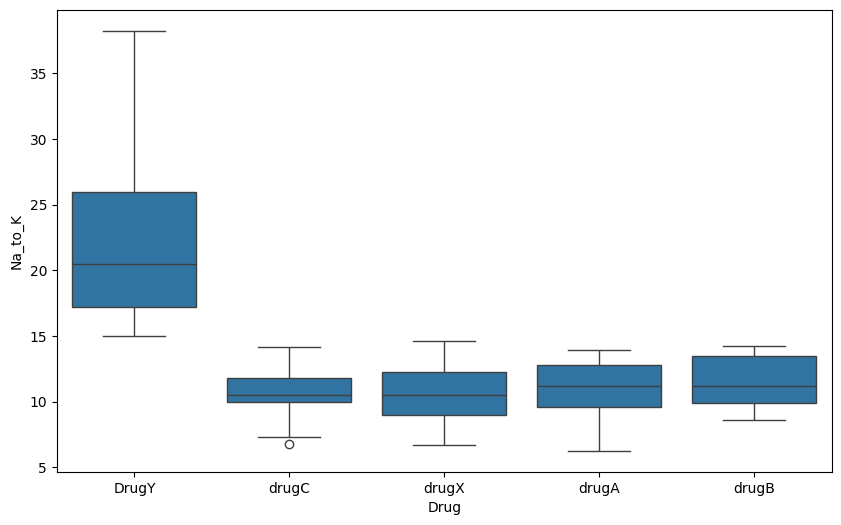

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Drug',
    y='Na_to_K',
    data=df
)

plt.show()

# Section 4: Data Preprocessing
Machine learning models require numerical data. Following categorical columns need encoding:

- Sex
- BP
- Cholestrol
- Drug

In [46]:
# Label Encoding

le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()
le_drug = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])

df['BP'] = le_bp.fit_transform(df['BP'])

df['Cholesterol'] = le_chol.fit_transform(df['Cholesterol'])

df['Drug'] = le_drug.fit_transform(df['Drug'])

print(df.head())
print('----------------------------------')

## Alternate way to do using loops

# le = LabelEncoder()
# for col in ['Sex', 'BP', 'Cholesterol', 'Drug']:
#     df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('Drug', axis=1)
y = df['Drug']

print(X.head())
print('----------------------------------')
print(y.head())
print('----------------------------------')

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size: ", X_train.shape[0])
print("Testing set size: ", X_test.shape[0])
print('----------------------------------')

   Age  Sex  BP  Cholesterol  Na_to_K  Drug
0   23    0   0            0   25.355     0
1   47    1   1            0   13.093     3
2   47    1   1            0   10.114     3
3   28    0   2            0    7.798     4
4   61    0   1            0   18.043     0
----------------------------------
   Age  Sex  BP  Cholesterol  Na_to_K
0   23    0   0            0   25.355
1   47    1   1            0   13.093
2   47    1   1            0   10.114
3   28    0   2            0    7.798
4   61    0   1            0   18.043
----------------------------------
0    0
1    3
2    3
3    4
4    0
Name: Drug, dtype: int64
----------------------------------
Training set size:  160
Testing set size:  40
----------------------------------


# Section 5: Building Machine Learning Model
We will use a **Decision Tree** Classifier for this multi-class classification problem.


In [50]:
# Initialize and train the model
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")
print('----------------------------------')

# Testing the model
y_pred = dt_model.predict(X_test)

print("Testing Complete")
print('----------------------------------')

# Evaluate Model
accuracy = accuracy_score(
    y_test,
    y_pred
)
print("Accuracy:", accuracy)
print('----------------------------------')



Model Trained Successfully
----------------------------------
Testing Complete
----------------------------------
Accuracy: 0.975
----------------------------------
